In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from meer21cm.telescope import dish_beam_sigma
from scipy.optimize import curve_fit
from meer21cm.power import bin_3d_to_cy, bin_3d_to_1d
from matplotlib.colors import LogNorm
import glob
from astropy.cosmology import Planck18
import matplotlib.ticker as tck
from meer21cm.util import dft_matrix
from meer21cm.inference import SamplerNautilus, extract_model_fitting_inputs
import corner

def get_k_modes():
    mock = get_mock(0)
    mock.sigma_beam_ch = sigma_beam_ch
    mock.grid_scheme = grid_scheme
    mock.downres_factor_transverse = ps_downres_transverse
    mock.downres_factor_radial = ps_downres_radial
    mock.get_enclosing_box()
    kperp_1 = mock.k_perp.copy()
    kpara_1 = mock.k_para.copy()
    kmode_1 = mock.k_mode.copy()
    kvec_1 = mock.k_vec.copy()
    dndz_box = mock.discrete_source_dndz(mock._box_voxel_redshift)
    mock.weights_1 = mock.counts_in_box.astype(np.float32)
    mock.apply_taper_to_field(1, axis=[0, 1, 2])
    mock.include_sky_sampling = [True, False]
    mock.compensate = [True, True]
    mock.include_beam = [True, False]
    mock.weights_field_2 = dndz_box
    mock.weights_grid_2 = ((dndz_box > 0) * mock.counts_in_box).astype("float")
    mock.apply_taper_to_field(2, axis=[0, 1, 2])
    return kperp_1, kpara_1, kmode_1, kvec_1, mock

kperp, kpara, kmode, kvec, mock = get_k_modes()
file_arr = glob.glob('/users/ztchen/scratch3/validation/full_sim_seed_*[0-9].npz')

In [2]:
karr = kperp, kpara, kmode, kvec

In [3]:
k_xy_sel = (
    (np.abs(kvec[0])<0.04)[:,None,None] 
    * (np.abs(kvec[0])>0.01)[:,None,None] 
    * (np.abs(kvec[1])<0.04)[None,:,None]
    * (np.abs(kvec[1])>0.01)[None,:,None] 
    * (np.abs(kvec[2])<10)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

In [81]:
phiclean3d_arr = []
pcrossclean3d_arr = []
pg3d_arr = []
power_before_arr = []
power_after_arr = []
phimod3d_arr = []
phi3d_arr = []
pcross3d_arr = []
for file in file_arr:
    data = np.load(file)
    phi3d_arr.append(data['phi3d'])
    pcross3d_arr.append(data['pcross3d'])
    phimod3d_arr.append(data['phimod3d'])
    pg3d_arr.append(data['pg3d'])
    phiclean3d_arr.append(data['phiclean3d'])
    pcrossclean3d_arr.append(data['pxclean3d'])
    power_before_arr.append(data['power_tf_before'])
    power_after_arr.append(data['power_tf_after'])

In [82]:
phimod3d_arr = np.array(phimod3d_arr)[0][None]
pg3d_arr = np.array(pg3d_arr)
phiclean3d_arr = np.array(phiclean3d_arr)
pcrossclean3d_arr = np.array(pcrossclean3d_arr)
power_before_arr = np.array(power_before_arr)
power_after_arr = np.array(power_after_arr)
phi3d_arr = np.array(phi3d_arr)
pcross3d_arr = np.array(pcross3d_arr)

In [6]:
phimod3d = mock.auto_power_tracer_1_model

In [7]:
# sanity check of mock attribute is correctly set
np.allclose(phimod3d_arr[0],phimod3d)

True

In [83]:
num_split = 20
pxclean1darr_sel, keff_sel = get_1d(pcrossclean3d_arr,karr,weights=k_xy_sel,num_split=num_split)
px1darr_sel, keff_sel = get_1d(pcross3d_arr,karr,weights=k_xy_sel,num_split=num_split)
phi1darr_sel, keff_sel = get_1d(phi3d_arr,karr,weights=k_xy_sel,num_split=num_split)
phiclean1darr_sel, keff_sel = get_1d(phiclean3d_arr,karr,weights=k_xy_sel,num_split=num_split)
pg1darr_sel, keff_sel = get_1d(pg3d_arr,karr,weights=k_xy_sel,num_split=num_split)
ptf_before, keff_sel = get_1d(power_before_arr,karr,weights=k_xy_sel,num_split=num_split)
ptf_after, keff_sel = get_1d(power_after_arr,karr,weights=k_xy_sel,num_split=num_split)
tf1darr_sel = (ptf_after/ptf_before).mean(0)

In [9]:
mock.k1dweights = k_xy_sel
mock.k1dbins = k1dbins

In [10]:
phimod1d_arr, _, _ = mock.get_1d_power(
    mock.auto_power_tracer_1_model
)
pgmod1d_arr, _, _ = mock.get_1d_power(
    mock.auto_power_tracer_2_model
)
pxmod1d_arr, _, _ = mock.get_1d_power(
    mock.cross_power_tracer_model
)

In [11]:
num_patch = 10

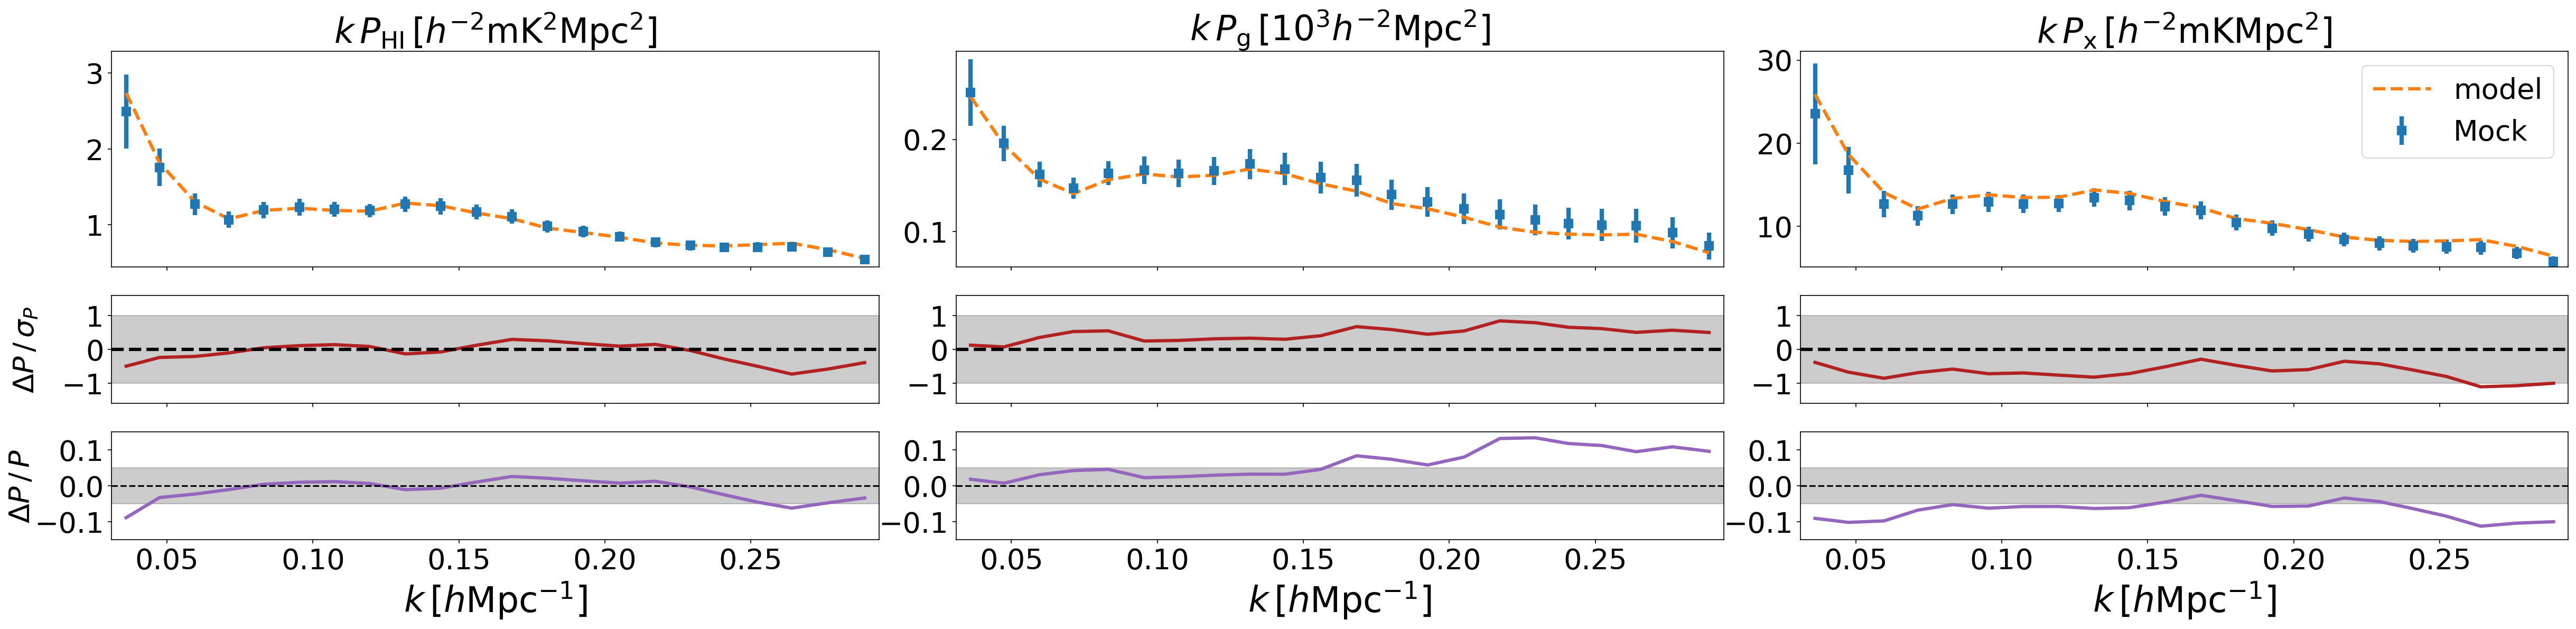

In [12]:
# repeat the validation check

keff = keff_sel/Planck18.h
plt.rcParams['font.size'] = 26
fig,axes=plt.subplots(
    3,3,figsize=(40,8),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.1},
)
ratio_min,ratio_max = (-1.6,1.6)
pmockarr = [phiclean1darr_sel/tf1darr_sel*1e6,pg1darr_sel/1e3,pxclean1darr_sel/tf1darr_sel*1e3]
pmodelarr = [phimod1d_arr*1e6,pgmod1d_arr/1e3,pxmod1d_arr*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = np.array(pmodelarr) * Planck18.h**3
ylabelarr= [
    r'$k\,P_{\rm HI}\,[ h^{-2} {\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm g}\,[ 10^3 h^{-2}{\rm Mpc^2}]$',
    r'$k\,P_{\rm x}\,[h^{-2} {\rm mKMpc^2}]$',
]
for i in range(3):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    axes[0,i].errorbar(
        keff,
        pdatad.mean(axis=0) * keff,
        yerr=pdatad.std(axis=0) * keff / np.sqrt(num_patch),
        label="Mock",
        ls='None',
        elinewidth=4,
        marker='s',
        markersize=8,
    )
    axes[0,i].plot(keff, pmodd * keff, label="model", ls="--",color='C1',lw=3)
    axes[0,i].set_ylim(np.nanmin(pmodd * keff) * 0.8, np.nanmax(pmodd * keff) * 1.2)
    if i == 2:
        axes[0,i].legend()
    axes[0,i].set_title(ylabelarr[i])
    axes[0,i].set_xlim(np.nanmin(keff)-0.005,np.nanmax(keff)+0.005)
    axes[1,i].plot(
        keff,
        (pdatad.mean(axis=0)- pmodd) / (pdatad.std(axis=0)) * np.sqrt(num_patch),
        color='firebrick',
        lw=3,
    )
    axes[1,i].fill_between(
        np.linspace(np.nanmin(keff) - 0.005, np.nanmax(keff) + 0.005, 100),
        -1,
        1,
        color="black",
        alpha=0.2,
    )
    axes[1,i].axhline(0, color="black", ls="--",lw=3)
    axes[1,i].set_xlim(np.nanmin(keff)-0.005,np.nanmax(keff)+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=20)
    axes[2,i].plot(
        keff,
        (pdatad.mean(axis=0)) / (pmodd) - 1,
        lw=3,
        color='C4',
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(np.nanmin(keff) - 0.005, np.nanmax(keff) + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[1,i].set_xlim(np.nanmin(keff)-0.005,np.nanmax(keff)+0.005)
    axes[2,i].set_ylim(-0.15, 0.15)
    axes[2,i].set_xlabel(r'$k\,[h{\rm Mpc^{-1}}]$', fontsize=32)
    if i ==0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)

In [13]:
# the first kbin is not sampled, remove it
mock.k1dbins = k1dbins[1:]

In [14]:
data_mock = np.concatenate(
    [phiclean1darr_sel[:,1:]/tf1darr_sel[1:],
    pg1darr_sel[:,1:],
    pxclean1darr_sel[:,1:]/tf1darr_sel[1:],],
    axis=-1,
)
data_vector = data_mock.mean(0)
data_cov = np.cov(data_mock,rowvar=False)

In [92]:
data_corr = np.corrcoef(data_mock,rowvar=False)
data_corr_orig = np.corrcoef(
    np.concatenate(
    [phi1darr_sel[:,1:],
    pg1darr_sel[:,1:],
    px1darr_sel[:,1:],],
    axis=-1,),rowvar=False
)

In [16]:
num_kbin = keff[1:].size

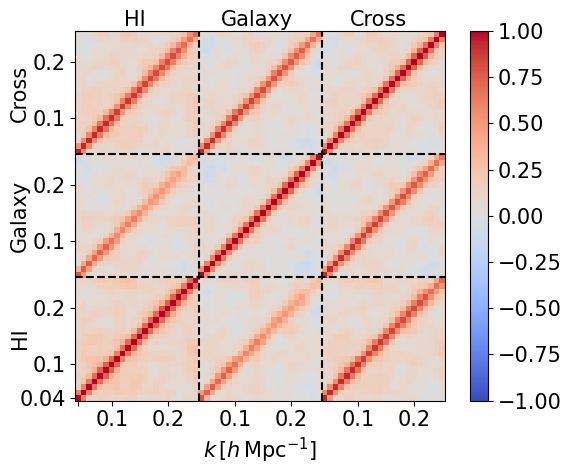

In [101]:
plt.rcParams.update({'font.size':15})
plt.imshow(data_corr_orig,vmin=-1,vmax=1,cmap='coolwarm',origin='lower')
ax = plt.gca()
tick_pos = np.array([6,16])
tick_pos = np.concatenate([tick_pos,tick_pos+num_kbin,tick_pos+num_kbin*2])
tick_pos = np.append([0],tick_pos,)
tick_label = (str(np.round(keff[6],1)),str(np.round(keff[16],1)),)*3
tick_label = (str(np.round(keff[1],2)),) + tick_label
ax.set_xticks(tick_pos)
ax.set_yticks(tick_pos)
ax.set_yticklabels(tick_label)
tick_label = list(tick_label)
tick_label[0] = ''
ax.set_xticklabels(tick_label)

for i in (np.arange(1,3)*num_kbin - 0.5):
    ax.axhline(i, linestyle='--', color='k') 
    ax.axvline(i, linestyle='--', color='k')
ax.set_xlabel(r'$k\,[h\,{\rm Mpc^{-1}}]$')
ax.text(0.16, 1.03, 'HI',
     horizontalalignment='center',
     verticalalignment='center',
     transform = ax.transAxes)
ax.text(0.49, 1.03, 'Galaxy',
     horizontalalignment='center',
     verticalalignment='center',
     transform = ax.transAxes)
ax.text(0.82, 1.03, 'Cross',
     horizontalalignment='center',
     verticalalignment='center',
     transform = ax.transAxes)
ax.text(-0.15, 0.83, 'Cross',
     horizontalalignment='center',
     verticalalignment='center',
     rotation=90,
     transform = ax.transAxes)
ax.text(-0.15, 0.5, 'Galaxy',
     horizontalalignment='center',
     verticalalignment='center',
     rotation=90,
     transform = ax.transAxes)
ax.text(-0.15, 0.17, 'HI',
     horizontalalignment='center',
     verticalalignment='center',
     rotation=90,
     transform = ax.transAxes)
plt.colorbar()
plt.savefig('corr_matrix.pdf')

In [18]:
ps_dict = extract_model_fitting_inputs(mock)

In [19]:
params_name = ['omega_hi', 'tracer_bias_1','tracer_bias_2', 'cross_coeff','sigma_v_1','sigma_v_2']
params_prior = [
    ['uniform',1e-6,1e-2],
    ['uniform',0.1,10.0],
    ['uniform',0.1,10.0],
    ['uniform',0.0,1.0],
    ['uniform',0.0,2000.0],
    ['uniform',0.0,2000.0],
]

In [20]:
sampler = SamplerNautilus(
    ps_dict, 
    data_vector, 
    data_cov, 
    params_name, 
    params_prior, 
    observables=['hi-auto','gg-auto','cross'], 
    save = True, 
    save_filename = 'fitting.h5',
    nthreads=31, 
    save_model_blobs=True, 
    do_hartlap_correction= True, 
    num_mocks=len(data_mock), 
    do_percival_correction=True,
)

In [21]:
#input_pars = np.array([np.atleast_1d(getattr(mock,name_i))[0] for name_i in params_name])

In [22]:
import multiprocessing as mp
mp.set_start_method('spawn')
sampler.run(resume=False,progress=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 76880    | N/A    | 10071 | -15.96   


In [26]:
points,log_w,log_l,blobs = sampler.get_posterior()

In [32]:
points[:,0] = np.log10(points[:,0])

In [34]:
input_pars = np.array([np.atleast_1d(getattr(mock,name_i))[0] for name_i in params_name])
input_pars[0] = np.log10(input_pars[0])

In [67]:
labelarr = [
    r'$\log_{10}[\Omega_{\rm HI}]$', 
    r'$b_{\rm HI}$',
    r'$b_{\rm gal}$', 
    r'$r_{\times}$',
    r'$\sigma_p^{\rm HI}$',
    r'$\sigma_p^{\rm gal}$',
]


In [73]:
('.2f',)*4 + ('.1f',)*2

('.2f', '.2f', '.2f', '.2f', '.1f', '.1f')

$\log_{10}[\Omega_{\rm HI}]$ = ${-3.24}_{-0.29}^{+0.18}$
$b_{\rm HI}$ = ${0.77}_{-0.49}^{+1.31}$
$b_{\rm gal}$ = ${1.03}_{-0.11}^{+0.11}$
$r_{\times}$ = ${0.77}_{-0.21}^{+0.12}$
$\sigma_p^{\rm HI}$ = ${138.94}_{-92.23}^{+109.25}$
$\sigma_p^{\rm gal}$ = ${154.81}_{-104.07}^{+129.14}$


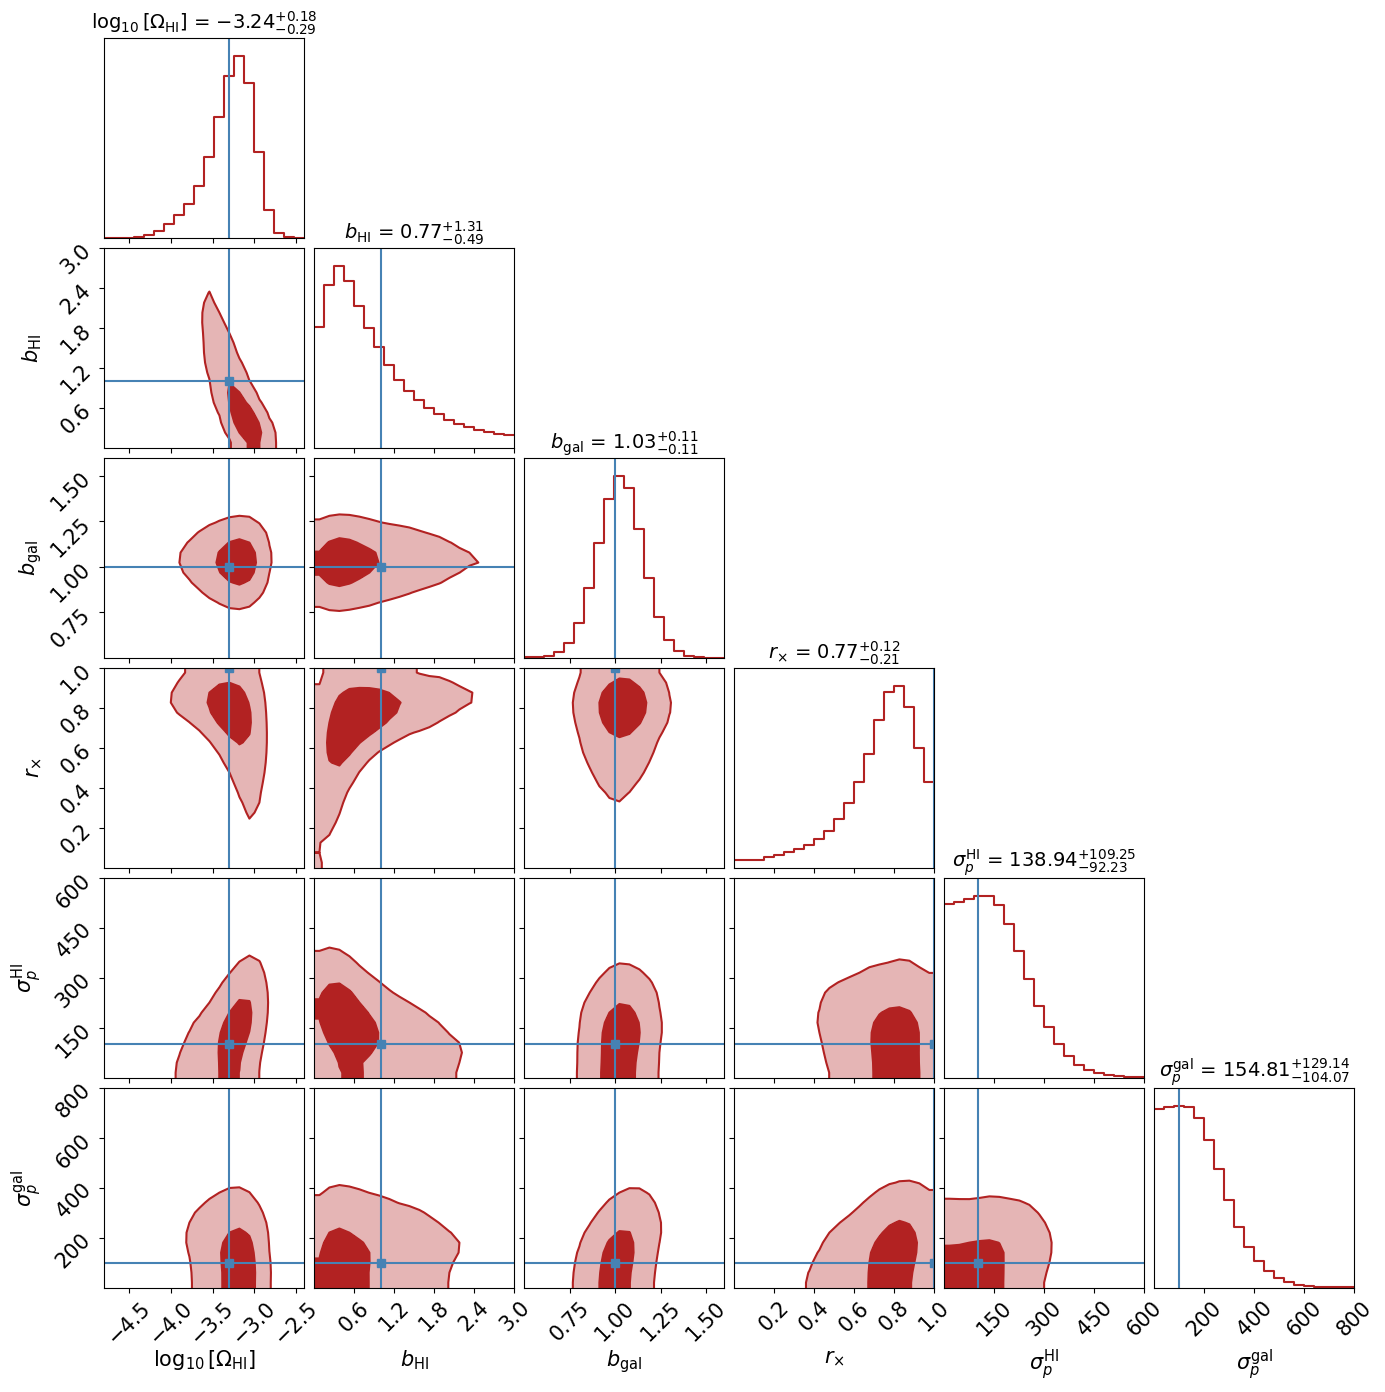

In [108]:
plot_range = (
    (-4.8,-2.4),
    (0,3),
    (0.5,1.6),
    (0,1),
    (0,600),
    (0,800),
)
fig = corner.corner(
    points,
    weights=np.exp(log_w),
    smooth=1.0,
    smooth1d=1.0,
    levels=(0.393, 0.864),
    plot_datapoints=False,
    plot_density=False,
    truths=input_pars,
    color='firebrick',
    fill_contours=True,
    range=plot_range,
    labels=labelarr,
    show_titles=True,
    #title_fmt=('.2f',)*4 + ('.1f',)*2,
    title_fmt='.2f',
    title_kwargs={'fontsize':14},
);
ax_list = fig.axes
for ax in ax_list:
    if ax.get_title():
        print(ax.get_title())
plt.savefig('plots/posterior.pdf')

In [107]:
len(ax_list)

36